# Statistical Feature Analysis Pipeline using the actual EBY dataset.

This notebook uses ` 1-second interval EBY datasets ` and follows the project analysis from data checks to return statistics.

**Dataset:** 22,438 rows × 437 columns  
**Columns:** `Time`, `Price`, 216 PB features, 72 VB features, 147 BB features

**Flow**
1. Load and inspect the data.
2. Check missing values, duplicates, and timestamps.
3. Run the ADF test on 10 selected features.
4. Check feature correlations.
5. Create the 5-observation forward log return.
6. Study its distribution and statistics.



In [1]:
# Imports

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)


In [2]:
# Load the data

CSV_PATH = "Copy of day201.csv"
df = pd.read_csv(CSV_PATH)

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (22438, 437)


,Time,Price,PB1_T1,PB1_T2,PB1_T3,PB1_T4,PB1_T5,PB1_T6,PB1_T7,PB1_T8,PB1_T9,PB1_T10,PB1_T11,PB1_T12,PB2_T1,PB2_T2,PB2_T3,PB2_T4,PB2_T5,PB2_T6,PB2_T7,PB2_T8,PB2_T9,PB2_T10,PB2_T11,PB2_T12,PB3_T1,PB3_T2,PB3_T3,PB3_T4,PB3_T5,PB3_T6,PB3_T7,PB3_T8,PB3_T9,PB3_T10,PB3_T11,PB3_T12,PB4_T1,PB4_T2,PB4_T3,PB4_T4,PB4_T5,PB4_T6,PB4_T7,PB4_T8,PB4_T9,PB4_T10,PB4_T11,PB4_T12,...,BB12_T2,BB12_T3,BB12_T4,BB12_T5,BB12_T6,BB12_T7,BB12_T8,BB12_T9,BB12_T10,BB12_T11,BB12_T12,BB13_T1,BB13_T2,BB13_T3,BB13_T4,BB13_T5,BB13_T6,BB13_T7,BB13_T8,BB13_T9,BB13_T10,BB13_T11,BB13_T12,BB14_T1,BB14_T2,BB14_T3,BB14_T4,BB14_T5,BB14_T6,BB14_T7,BB14_T8,BB14_T9,BB14_T10,BB14_T11,BB14_T12,BB15_T1,BB15_T2,BB15_T3,BB15_T4,BB15_T5,BB15_T6,BB15_T7,BB15_T8,BB15_T9,BB15_T10,BB15_T11,BB15_T12,BB23,BB24,BB25
0,00:00:00,100.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,00:00:01,99.995941,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,00:00:02,99.996508,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,00:00:03,99.987037,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,00:00:04,99.982410,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,99.990338,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Basic inspection

Check the shape, data types, missing values, and duplicate rows.

We avoid dropping every row containing any missing value because the dataset has many feature columns.


In [22]:
# Quick data check

print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Duplicate rows:", df.duplicated().sum())

overview = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "non_null": df.notna().sum(),
    "missing": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2)
})

display(overview.head(50))


Rows: 22438
Columns: 438
Duplicate rows: 0


,dtype,non_null,missing,missing_pct
Time,str,22438,0,0.00
Price,float64,22438,0,0.00
PB1_T1,float64,22433,5,0.02
PB1_T2,float64,22428,10,0.04
PB1_T3,float64,22408,30,0.13
PB1_T4,float64,22378,60,0.27
PB1_T5,float64,22348,90,0.40
PB1_T6,float64,22318,120,0.53
PB1_T7,float64,22138,300,1.34
PB1_T8,float64,21838,600,2.67


In [4]:
# Make feature columns numeric

for col in df.columns:
    if col != "Time":
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Remove exact duplicate rows.
df = df.drop_duplicates().copy()

print("Shape after duplicate removal:", df.shape)


Shape after duplicate removal: (22438, 437)


In [5]:
# Check timestamps

if "Time" in df.columns:
    parsed_time = pd.to_datetime(df["Time"], errors="coerce")
    print("Parsable timestamps:", parsed_time.notna().sum(), "/", len(df))
    display(df[["Time"]].head(10))

    if parsed_time.notna().sum() > 1:
        diffs = parsed_time.dropna().sort_values().diff().dropna()
        print("Most common timestamp gaps:")
        display(diffs.value_counts().head(10))


Parsable timestamps: 22438 / 22438


,Time
0,00:00:00
1,00:00:01
2,00:00:02
3,00:00:03
4,00:00:04
5,00:00:05
6,00:00:06
7,00:00:07
8,00:00:08
9,00:00:09


Most common timestamp gaps:


Time
0 days 00:00:01    22437
Name: count, dtype: int64

In [6]:
# Check Price

PRICE_COL = "Price"

if PRICE_COL not in df.columns:
    raise KeyError("Price column was not found.")

price = pd.to_numeric(df[PRICE_COL], errors="coerce")

print("Valid Price values:", price.notna().sum())
print("Missing Price values:", price.isna().sum())
display(price.describe())


Valid Price values: 22438
Missing Price values: 0


count    22438.000000
mean        99.654085
std          0.143429
min         99.344211
25%         99.562662
50%         99.632169
75%         99.705146
max        100.122647
Name: Price, dtype: float64

# ADF stationarity test

The Augmented Dickey-Fuller (ADF) test checks for a unit root.

- \(H_0\): the series has a unit root (non-stationary).
- \(H_1\): the series does not have a unit root.

At the 5% level, `p < 0.05` means we reject \(H_0\).

A significant ADF result does not by itself mean a feature is predictable or profitable.


In [7]:
# Features used for ADF

ADF_FEATURES = ['PB1_T1', 'PB1_T2', 'PB1_T3', 'PB1_T4', 'PB1_T5', 'PB1_T6', 'PB1_T7', 'PB1_T8', 'PB1_T9', 'PB1_T10']

for i, col in enumerate(ADF_FEATURES, 1):
    print(i, col)


1 PB1_T1
2 PB1_T2
3 PB1_T3
4 PB1_T4
5 PB1_T5
6 PB1_T6
7 PB1_T7
8 PB1_T8
9 PB1_T9
10 PB1_T10


In [8]:
# ADF test helper

def run_adf(series, feature_name):
    x = pd.to_numeric(series, errors="coerce").dropna()

    if len(x) < 25:
        return {
            "feature": feature_name,
            "n": len(x),
            "adf_statistic": np.nan,
            "p_value": np.nan,
            "used_lag": np.nan,
            "stationary_at_5pct": "Not enough data"
        }

    result = adfuller(x, autolag="AIC")

    return {
        "feature": feature_name,
        "n": len(x),
        "adf_statistic": result[0],
        "p_value": result[1],
        "used_lag": result[2],
        "stationary_at_5pct": "Yes" if result[1] < 0.05 else "No / inconclusive"
    }


In [9]:
# Run the test

adf_results = pd.DataFrame(
    [run_adf(df[col], col) for col in ADF_FEATURES]
)

display(adf_results.sort_values("p_value"))


,feature,n,adf_statistic,p_value,used_lag,stationary_at_5pct
0,PB1_T1,22433,-20.388086,0.000000e+00,47,Yes
1,PB1_T2,22428,-20.435947,0.000000e+00,47,Yes
2,PB1_T3,22408,-18.027981,2.682022e-30,47,Yes
3,PB1_T4,22378,-18.025508,2.686700e-30,47,Yes
4,PB1_T5,22348,-14.292213,1.269924e-26,47,Yes
5,PB1_T6,22318,-11.653099,2.015200e-21,42,Yes
6,PB1_T7,22138,-7.020290,6.570054e-10,32,Yes
7,PB1_T8,21838,-4.782346,5.877668e-05,16,Yes
8,PB1_T9,21538,-3.670045,4.554786e-03,24,Yes
9,PB1_T10,20938,-2.918463,4.324275e-02,15,Yes


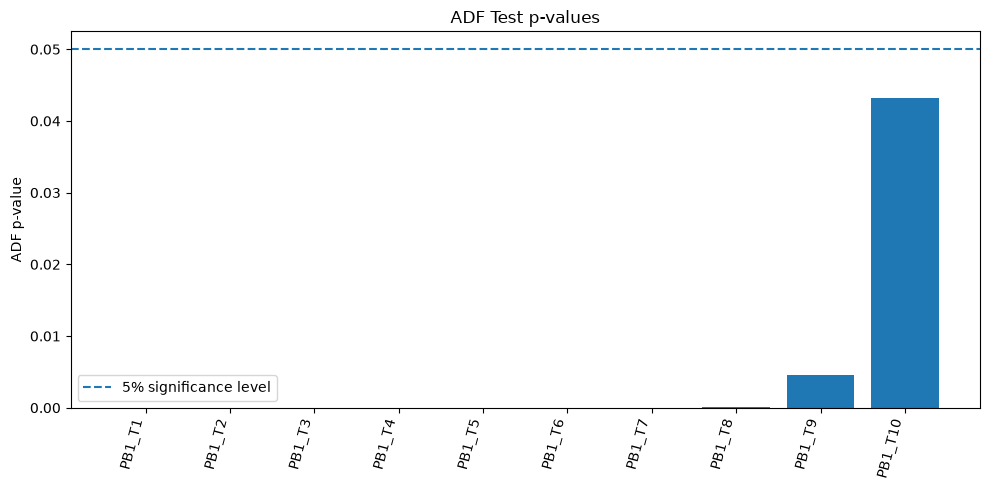

In [10]:
# Plot p-values

plot_df = adf_results.dropna(subset=["p_value"]).sort_values("p_value")

plt.figure(figsize=(10, 5))
plt.bar(plot_df["feature"], plot_df["p_value"])
plt.axhline(0.05, linestyle="--", label="5% significance level")
plt.xticks(rotation=75, ha="right")
plt.ylabel("ADF p-value")
plt.title("ADF Test p-values")
plt.legend()
plt.tight_layout()
plt.show()


# Feature correlation

Pearson correlation measures the strength of a linear relationship between two variables:

\[ρ(X,Y) = Cov(X,Y)/σxσy​
\]

It ranges from -1 to +1. A low correlation means less linear redundancy, but it does not prove independence.


In [11]:
# Features used for correlation

CORR_FEATURES = ['PB1_T1', 'PB1_T2', 'PB1_T3', 'PB1_T4', 'PB1_T5', 'PB1_T6', 'PB1_T7', 'PB1_T8', 'PB1_T9', 'PB1_T10', 'PB1_T11', 'PB1_T12', 'PB2_T1', 'PB2_T2', 'PB2_T3', 'PB2_T4', 'PB2_T5', 'PB2_T6', 'PB2_T7', 'PB2_T8', 'PB2_T9', 'PB2_T10', 'PB2_T11', 'PB2_T12', 'PB3_T1']

print("Number of features:", len(CORR_FEATURES))
print(CORR_FEATURES)


Number of features: 25
['PB1_T1', 'PB1_T2', 'PB1_T3', 'PB1_T4', 'PB1_T5', 'PB1_T6', 'PB1_T7', 'PB1_T8', 'PB1_T9', 'PB1_T10', 'PB1_T11', 'PB1_T12', 'PB2_T1', 'PB2_T2', 'PB2_T3', 'PB2_T4', 'PB2_T5', 'PB2_T6', 'PB2_T7', 'PB2_T8', 'PB2_T9', 'PB2_T10', 'PB2_T11', 'PB2_T12', 'PB3_T1']


In [12]:
# Correlation matrix

corr_matrix = df[CORR_FEATURES].corr(method="pearson")
display(corr_matrix)


,PB1_T1,PB1_T2,PB1_T3,PB1_T4,PB1_T5,PB1_T6,PB1_T7,PB1_T8,PB1_T9,PB1_T10,PB1_T11,PB1_T12,PB2_T1,PB2_T2,PB2_T3,PB2_T4,PB2_T5,PB2_T6,PB2_T7,PB2_T8,PB2_T9,PB2_T10,PB2_T11,PB2_T12,PB3_T1
PB1_T1,1.000000,0.696470,0.409430,0.292569,0.231329,0.194129,0.119058,0.080633,0.076438,0.051012,0.047284,0.019389,0.717246,0.479147,0.284859,0.220551,0.167815,0.136091,0.089249,0.047477,0.050113,0.030334,0.021234,0.040847,0.834121
PB1_T2,0.696470,1.000000,0.580069,0.415746,0.329415,0.276331,0.170233,0.115310,0.108598,0.072878,0.066949,0.027300,-0.000488,0.710308,0.402583,0.312937,0.239372,0.194698,0.127499,0.067882,0.072160,0.043303,0.030333,0.057442,0.792406
PB1_T3,0.409430,0.580069,1.000000,0.720761,0.574902,0.489008,0.298062,0.205106,0.183562,0.127824,0.113780,0.050960,0.007637,0.008257,0.691501,0.530744,0.427666,0.350840,0.217157,0.124856,0.123658,0.076753,0.052785,0.097639,0.510456
PB1_T4,0.292569,0.415746,0.720761,1.000000,0.823063,0.700172,0.431813,0.303242,0.249772,0.182686,0.161853,0.078145,0.004436,-0.000115,-0.002332,0.713128,0.614329,0.506603,0.307523,0.199910,0.164325,0.111869,0.078131,0.136054,0.366029
PB1_T5,0.231329,0.329415,0.574902,0.823063,1.000000,0.868500,0.527843,0.377265,0.301695,0.222958,0.200292,0.104390,0.002773,0.001435,-0.027281,0.300700,0.728704,0.639253,0.371660,0.257767,0.195925,0.137463,0.098128,0.168778,0.288823
PB1_T6,0.194129,0.276331,0.489008,0.700172,0.868500,1.000000,0.610583,0.431289,0.350193,0.252990,0.232297,0.127972,0.002356,-0.003394,-0.023403,-0.001208,0.437793,0.732601,0.432930,0.295638,0.229532,0.153051,0.113826,0.197547,0.243841
PB1_T7,0.119058,0.170233,0.298062,0.431813,0.527843,0.610583,1.000000,0.671760,0.554145,0.402446,0.375473,0.228642,0.000543,-0.000585,-0.020371,0.007153,0.024367,0.018325,0.738544,0.444099,0.376455,0.229901,0.206346,0.318770,0.145883
PB1_T8,0.080633,0.115310,0.205106,0.303242,0.377265,0.431289,0.671760,1.000000,0.784880,0.615712,0.524980,0.337468,0.000047,-0.002104,-0.020802,0.002081,0.028294,0.030573,-0.003306,0.718595,0.571588,0.370610,0.299422,0.358609,0.103515
PB1_T9,0.076438,0.108598,0.183562,0.249772,0.301695,0.350193,0.554145,0.784880,1.000000,0.752334,0.681101,0.428226,0.000519,0.001947,0.002913,0.006853,0.014880,0.017300,0.032592,0.276104,0.722791,0.456604,0.425511,0.398949,0.093989
PB1_T10,0.051012,0.072878,0.127824,0.182686,0.222958,0.252990,0.402446,0.615712,0.752334,1.000000,0.891303,0.592065,-0.000094,-0.001165,-0.007752,0.006934,0.015664,0.014319,-0.021066,0.012056,0.178947,0.684514,0.553969,0.480866,0.058597


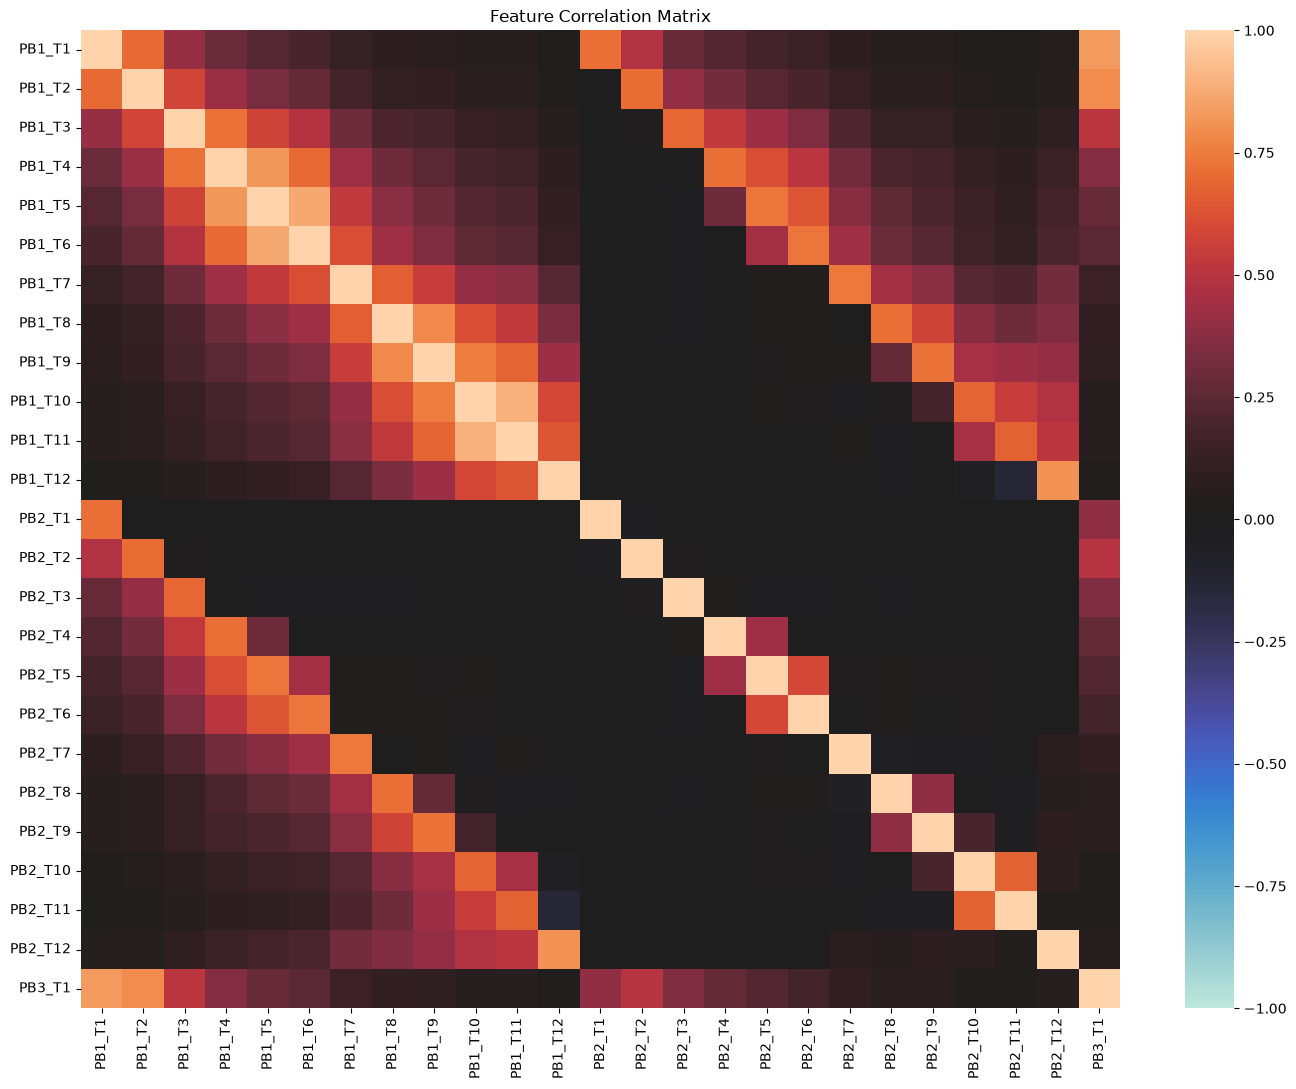

In [13]:
# Correlation heatmap

plt.figure(figsize=(14, 11))
sns.heatmap(
    corr_matrix,
    center=0,
    vmin=-1,
    vmax=1
)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()


In [14]:
# Find the strongest pairs

pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        a = corr_matrix.columns[i]
        b = corr_matrix.columns[j]
        value = corr_matrix.iloc[i, j]
        if pd.notna(value):
            pairs.append((a, b, value, abs(value)))

pairs_df = pd.DataFrame(
    pairs,
    columns=["feature_1", "feature_2", "correlation", "abs_correlation"]
).sort_values("abs_correlation", ascending=False)

display(pairs_df.head(20))


,feature_1,feature_2,correlation,abs_correlation
180,PB1_T10,PB1_T11,0.891303,0.891303
90,PB1_T5,PB1_T6,0.868500,0.868500
23,PB1_T1,PB3_T1,0.834121,0.834121
69,PB1_T4,PB1_T5,0.823063,0.823063
220,PB1_T12,PB2_T12,0.808898,0.808898
46,PB1_T2,PB3_T1,0.792406,0.792406
147,PB1_T8,PB1_T9,0.784880,0.784880
164,PB1_T9,PB1_T10,0.752334,0.752334
140,PB1_T7,PB2_T7,0.738544,0.738544
121,PB1_T6,PB2_T6,0.732601,0.732601


# Forward log return

For each row t,\
The 5-observation forward log return is

\[r(t,t+5) = ln(P(t+5)/​Pt​​)​
\]

`shift(-5)` brings the price from five rows ahead to the current row.




In [15]:
# Create the forward return

HORIZON = 5

df["forward_log_return_5"] = np.log(
    df[PRICE_COL].shift(-HORIZON) / df[PRICE_COL]
)

returns = (
    df["forward_log_return_5"]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

print("Valid forward returns:", len(returns))
display(returns.describe())


Valid forward returns: 22433


count    22433.000000
mean        -0.000001
std          0.000085
min         -0.000814
25%         -0.000052
50%          0.000000
75%          0.000050
max          0.000516
Name: forward_log_return_5, dtype: float64

In [16]:
# Check one value by hand

idx = df["forward_log_return_5"].first_valid_index()

if idx is not None:
    pos = df.index.get_loc(idx)
    if pos + HORIZON < len(df):
        p0 = df.iloc[pos][PRICE_COL]
        p5 = df.iloc[pos + HORIZON][PRICE_COL]
        direct = np.log(p5 / p0)

        print("Current Price :", p0)
        print("Future Price  :", p5)
        print("Direct return :", direct)
        print("Stored return :", df.loc[idx, "forward_log_return_5"])


Current Price : 100.0
Future Price  : 99.98241046468236
Direct return : -0.00017591082457830696
Stored return : -0.00017591082457830696


# Return distribution

We look at the mean, standard deviation, skewness, and excess kurtosis of the forward returns.

Positive excess kurtosis indicates heavier tails than a normal distribution.


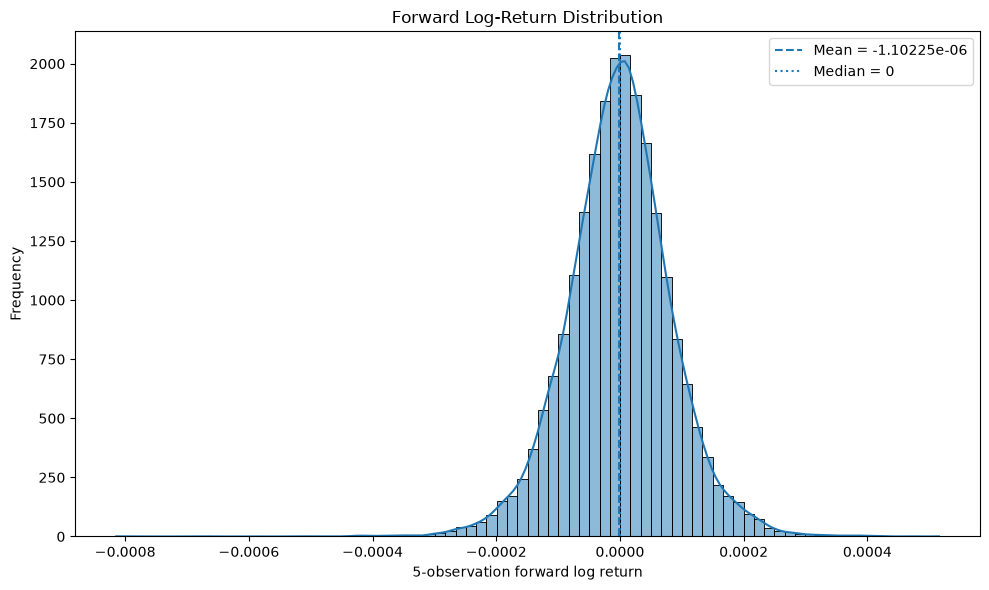

In [17]:
# Return histogram

plt.figure(figsize=(10, 6))
sns.histplot(returns, bins=80, kde=True)
plt.axvline(returns.mean(), linestyle="--", label=f"Mean = {returns.mean():.6g}")
plt.axvline(returns.median(), linestyle=":", label=f"Median = {returns.median():.6g}")
plt.xlabel("5-observation forward log return")
plt.ylabel("Frequency")
plt.title("Forward Log-Return Distribution")
plt.legend()
plt.tight_layout()
plt.show()


In [18]:
# Return statistics

return_stats = pd.Series({
    "count": returns.count(),
    "mean": returns.mean(),
    "median": returns.median(),
    "std_dev": returns.std(),
    "variance": returns.var(),
    "minimum": returns.min(),
    "maximum": returns.max(),
    "skewness": returns.skew(),
    "excess_kurtosis": returns.kurtosis()
})

display(return_stats.to_frame("value"))


,value
count,2.243300e+04
mean,-1.102245e-06
median,0.000000e+00
std_dev,8.525756e-05
variance,7.268851e-09
minimum,-8.143350e-04
maximum,5.155792e-04
skewness,-1.476845e-01
excess_kurtosis,2.301853e+00


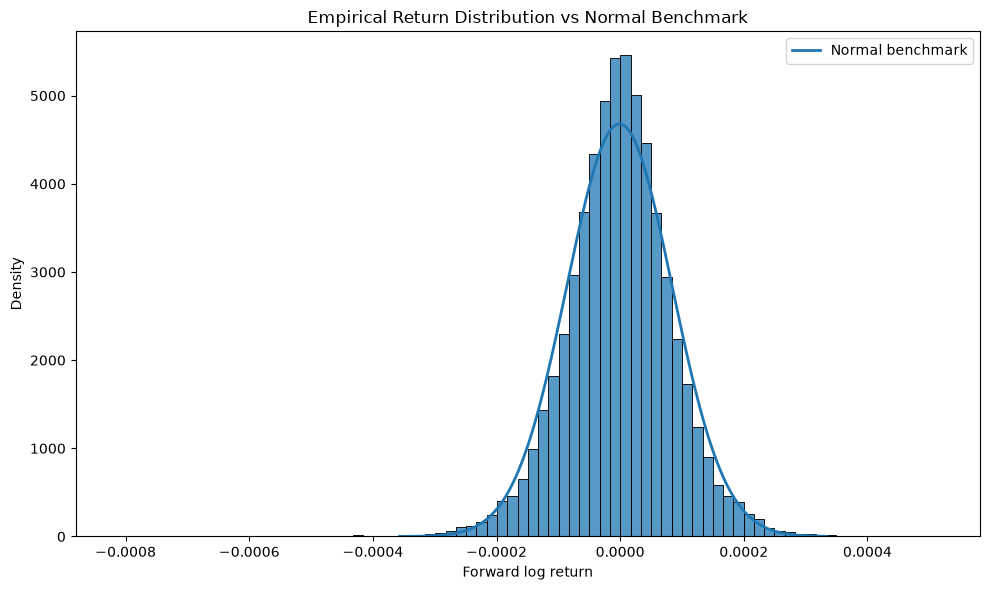

In [19]:
# Compare with a normal benchmark

mu = returns.mean()
sigma = returns.std()

if sigma > 0:
    x = np.linspace(returns.quantile(0.001), returns.quantile(0.999), 500)
    normal_pdf = (
        1 / (sigma * np.sqrt(2 * np.pi))
        * np.exp(-0.5 * ((x - mu) / sigma) ** 2)
    )

    plt.figure(figsize=(10, 6))
    sns.histplot(returns, bins=80, stat="density", kde=False)
    plt.plot(x, normal_pdf, linewidth=2, label="Normal benchmark")
    plt.xlabel("Forward log return")
    plt.ylabel("Density")
    plt.title("Empirical Return Distribution vs Normal Benchmark")
    plt.legend()
    plt.tight_layout()
    plt.show()
